
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67       187
           1       0.88      0.77      0.82       413

    accuracy                           0.77       600
   macro avg       0.74      0.77      0.75       600
weighted avg       0.79      0.77      0.77       600

Confusion Matrix:
[[143  44]
 [ 96 317]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       187
           1       1.00      0.98      0.99       413

    accuracy                           0.99       600
   macro avg       0.98      0.99      0.98       600
weighted avg       0.99      0.99      0.99       600

Confusion Matrix:
[[187   0]
 [  8 405]]

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       187
           1       0.96   

<Figure size 1000x600 with 0 Axes>

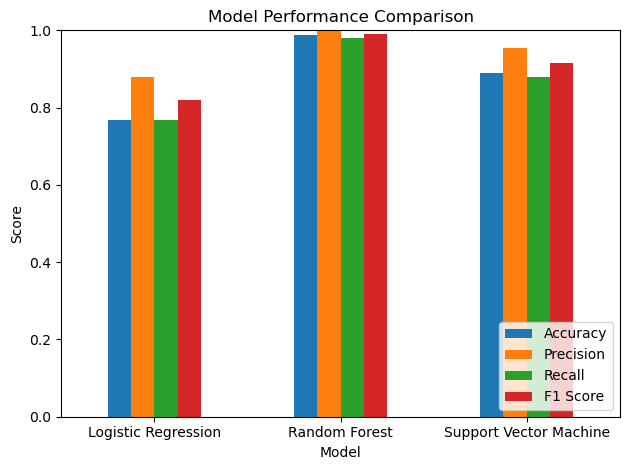


Model Performance Summary:
                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.766667   0.878116  0.767554  0.819121
1           Random Forest  0.986667   1.000000  0.980630  0.990220
2  Support Vector Machine  0.888333   0.955263  0.878935  0.915511

Best Model Selection: Random Forest
Selected based on highest F1 Score: 0.9902
- Precision: 1.0000
- Recall: 0.9806


In [15]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, 
                            recall_score, f1_score, confusion_matrix,
                            classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r"C:\Users\Rohith\Downloads\Flyzy Flight Cancellation - Sheet1 (1).csv")
target = 'Flight_Cancelled'
X = df.drop(target, axis=1)
y = df[target]

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', probability=True, random_state=42)
}

# Store results and pipelines
results = []
pipelines = {}

# Train and evaluate models
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Store pipeline for later use
    pipelines[name] = pipeline
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    # Print classification report
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Create results dataframe
results_df = pd.DataFrame(results)

# Save results to CSV
results_df.to_csv('classification_model_results.csv', index=False)
print("\nResults saved to 'classification_model_results.csv'")

# Find best model based on F1 Score (balanced metric for imbalanced data)
best_model_info = results_df.loc[results_df['F1 Score'].idxmax()]
best_model_name = best_model_info['Model']
best_model = pipelines[best_model_name]

# Save best model to file
joblib.dump(best_model, 'best_flight_cancellation_model.pkl')
print(f"\nBest model '{best_model_name}' saved to 'best_flight_cancellation_model.pkl'")

# Plot comparison
plt.figure(figsize=(10, 6))
results_df.set_index('Model').plot(kind='bar', rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')  # Save the plot
plt.show()

# Display results and best model selection
print("\n" + "="*50)
print("Model Performance Summary:")
print("="*50)
print(results_df)

print("\n" + "="*50)
print(f"Best Model Selection: {best_model_name}")
print("="*50)
print(f"Selected based on highest F1 Score: {best_model_info['F1 Score']:.4f}")
print(f"- Precision: {best_model_info['Precision']:.4f}")
print(f"- Recall: {best_model_info['Recall']:.4f}")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Rohith\Downloads\datasets1603366608907\datasets\computers.csv")

In [3]:
df.head()


,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74


In [6]:
mean=df['Minutes'].mean()

In [7]:
mean

97.21428571428571

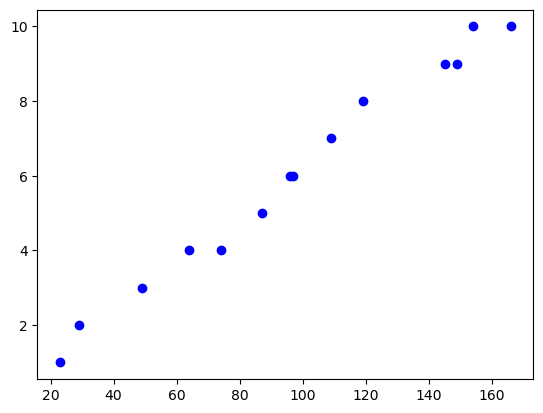

In [9]:
plt.scatter(df['Minutes'],df['Units'],c='blue',marker='o')

Text(7.5, 99.21428571428571, 'Mean repair time')

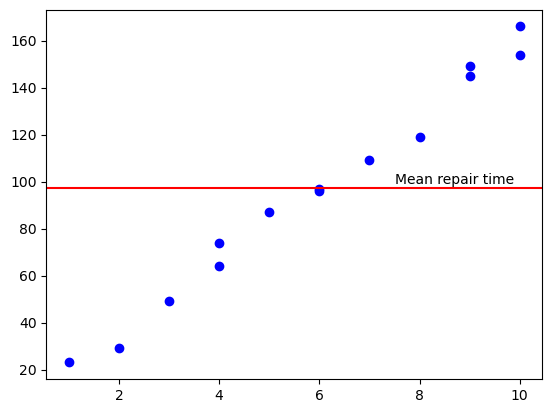

In [14]:
plt.scatter(df['Units'],df['Minutes'],c='blue')
plt.axhline(y=mean,c='r')
plt.annotate("Mean repair time",xy = (7.5,mean+2))

Text(8, 100.21428571428571, 'Mean repair time')

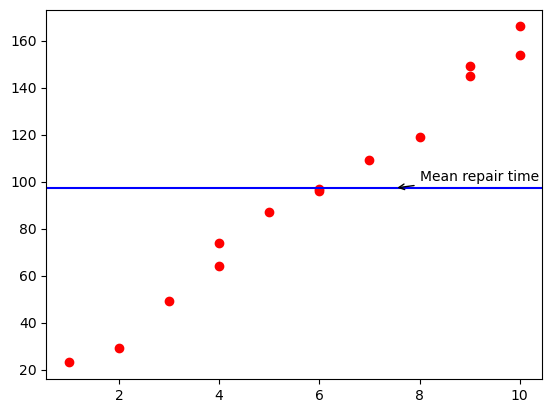

In [17]:
plt.scatter(df['Units'],df['Minutes'],c='r')
plt.axhline(y=mean,c='b')
plt.annotate("Mean repair time", xy=(7.5, mean),
             xytext=(8, mean+3),
             arrowprops=dict(arrowstyle="->"))

In [24]:
df['model0'] = df['Minutes'].mean()
df['model1'] = 10 + 12 * df['Units']
df['model2'] = 6 + 18 * df['Units']

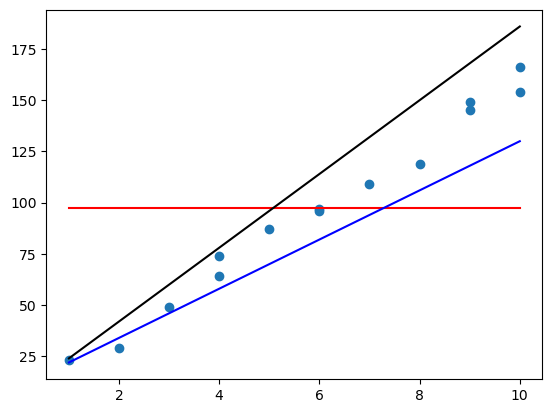

In [27]:
fig,ax=plt.subplots()
ax.scatter(x='Units',y='Minutes',data=df,label='actual repair time')
ax.plot(df['Units'],df['model0'],c='r',label='model0')
ax.plot(df['Units'],df['model1'],c='b',label='model1')
ax.plot(df['Units'],df['model2'],c='black',label='model2')

In [28]:
df.columns

Index(['Units', 'Minutes', 97.21428571428571, 'model0', 'model1', 'model2'], dtype='object')

In [29]:
df.head()

,Units,Minutes,97.214286,model0,model1,model2
0,1,23,97.214286,97.214286,22,24
1,2,29,97.214286,97.214286,34,42
2,3,49,97.214286,97.214286,46,60
3,4,64,97.214286,97.214286,58,78
4,4,74,97.214286,97.214286,58,78


In [32]:
model0=pd.DataFrame({"Units":df['Units'],"Actual":df['Minutes'],"predict":df['model0'],"eror":df['model0']-df['Minutes']})

In [33]:
model0

,Units,Actual,predict,eror
0,1,23,97.214286,74.214286
1,2,29,97.214286,68.214286
2,3,49,97.214286,48.214286
3,4,64,97.214286,33.214286
4,4,74,97.214286,23.214286
5,5,87,97.214286,10.214286
6,6,96,97.214286,1.214286
7,6,97,97.214286,0.214286
8,7,109,97.214286,-11.785714
9,8,119,97.214286,-21.785714


In [36]:
print(sum(model0['eror']**2))

27768.357142857145


In [37]:
df.head()

,Units,Minutes,97.214286,model0,model1,model2
0,1,23,97.214286,97.214286,22,24
1,2,29,97.214286,97.214286,34,42
2,3,49,97.214286,97.214286,46,60
3,4,64,97.214286,97.214286,58,78
4,4,74,97.214286,97.214286,58,78


In [38]:
mean=df['Minutes'].mean()

In [39]:
mean

97.21428571428571

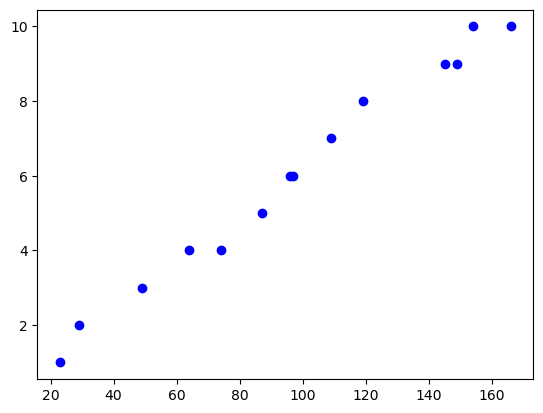

In [41]:
plt.scatter(df['Minutes'],df['Units'],c='b',marker='o')

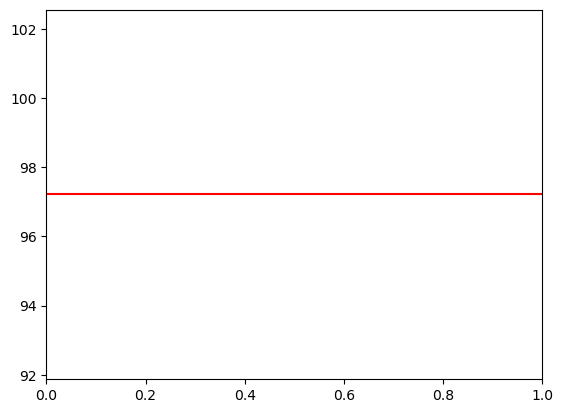

In [44]:
plt.axhline(y=mean,c='r')

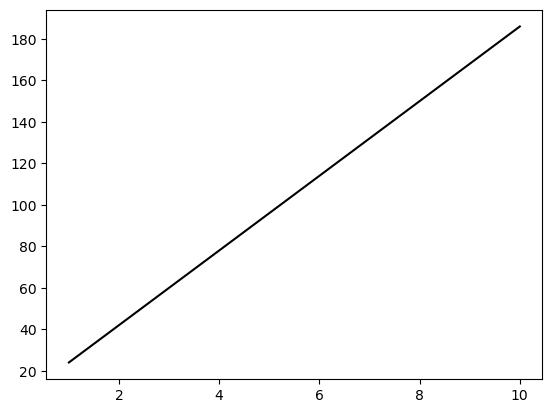

In [48]:
fig,ax=plt.subplots()
ax.plot(df['Units'],df['model2'],c='black')

In [49]:
model2=pd.DataFrame({"Units":df['Units'],"Actual":df['Minutes'],"Predict":df['model2'],"error":df['model2']-df["Minutes"]})

In [50]:
model2

,Units,Actual,Predict,error
0,1,23,24,1
1,2,29,42,13
2,3,49,60,11
3,4,64,78,14
4,4,74,78,4
5,5,87,96,9
6,6,96,114,18
7,6,97,114,17
8,7,109,132,23
9,8,119,150,31


In [52]:
print(sum(model2['error'])**2)

55225
